# Logistic Regression with Python(Scikit learning)

We will be working with the [Titanic Data Set from Kaggle](https://www.kaggle.com/c/titanic). This is a very famous data set, We'll be trying to predict a classification- survival or deceased. We'll use a "semi-cleaned" version of the titanic data set.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
#importing the dataset
train = pd.read_csv("D:/5 month Learning/Python for Data Science/Py_DS_ML_Bootcamp-master/Refactored_Py_DS_ML_Bootcamp-master/13-Logistic-Regression/titanic_train.csv")

In [95]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis

Let's begin some exploratory data analysis! We'll start by checking out missing data!

## Missing Data

We can use seaborn to create a simple heatmap to see where we are missing data!

In [96]:
train.isnull()
#which is a matrix type of table, so we can use it for heatmap

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

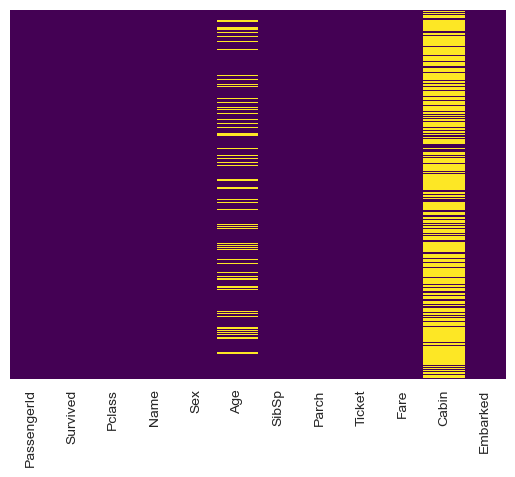

In [97]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False,cmap="viridis")

We have missing data for Age, but the proportion of age missing is likely small, which can be reasonanly replaced with some imputation. But the cabin column missing too much data, planning to drop the entire column for this notebook work.

<Axes: xlabel='Survived', ylabel='count'>

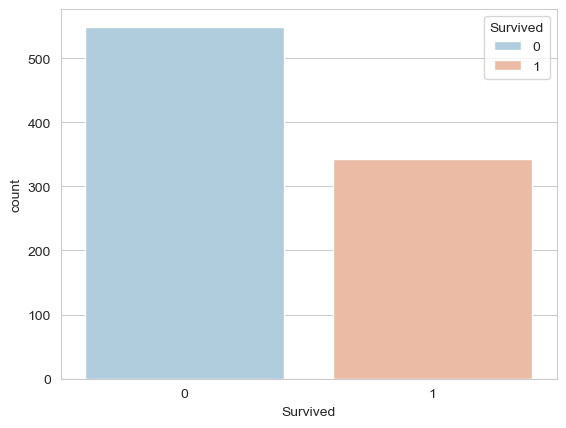

In [98]:
#setting the plotting background
sns.set_style("whitegrid")

#checking the target column if the class is imbalanced or not
sns.countplot(x="Survived",hue="Survived", data = train, palette='RdBu_r')

Normally the proportion of Survived people is less than not survived ones

<Axes: xlabel='Survived', ylabel='count'>

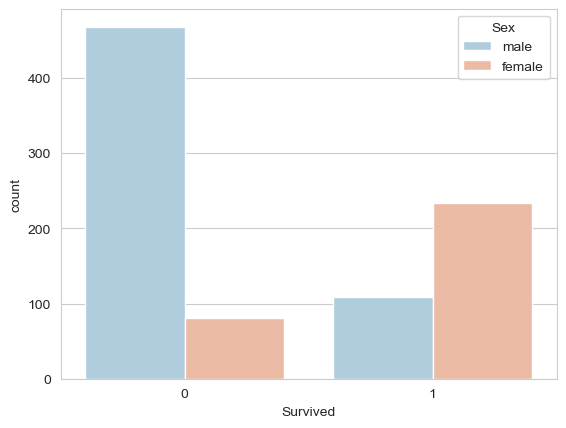

In [99]:
#setting the plotting background
sns.set_style("whitegrid")

#checking the target column, also seeing comparison of male or female survival rate
sns.countplot(x="Survived",hue="Sex", data = train, palette='RdBu_r')

Among the survived peoples , the number female were more, and among died people men were the most

<Axes: xlabel='Survived', ylabel='count'>

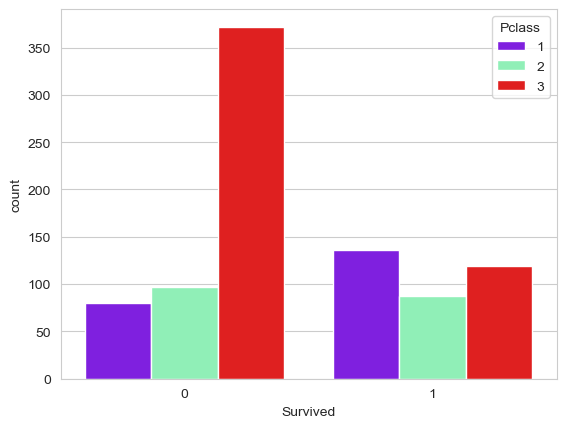

In [100]:
sns.set_style('whitegrid')

#checking survival rates in terms of class of Passengers
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

Among dead ones , a large number of them were in Passenger class 3, while among the survived ones , 1st class passengers survived more than other 2 classes.  

<Axes: xlabel='Age', ylabel='Count'>

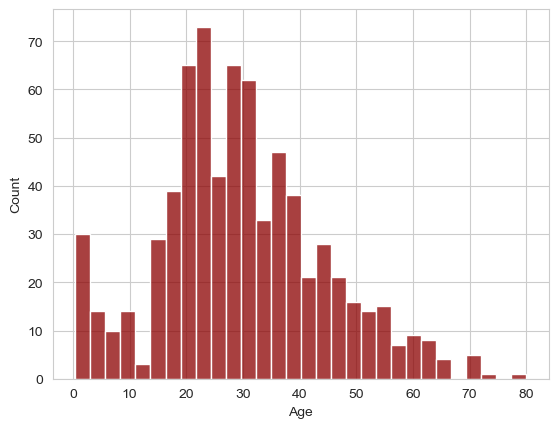

In [101]:
#seeing the distribution of Age
sns.histplot(train["Age"].dropna(),kde=False,color='darkred', bins = 30)

Most of the passengers were from age 20 to 30 years


<Axes: xlabel='SibSp', ylabel='count'>

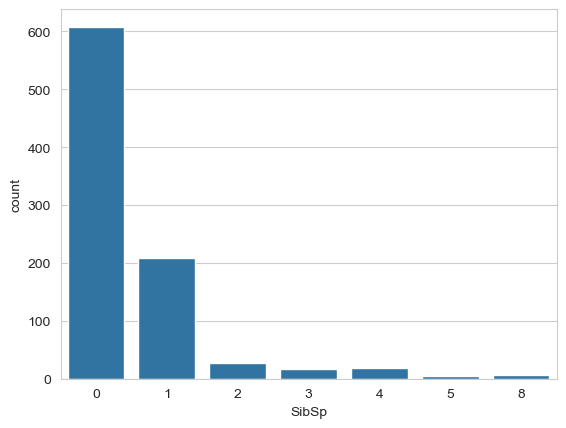

In [102]:
#visualizing the count of Siblings/spouse column
sns.countplot(x='SibSp', data=train)

In [103]:
train.shape

(891, 12)

From around 900 passengers ,around 600 of them travelled without any spouse or siblings

<Axes: xlabel='Fare', ylabel='Count'>

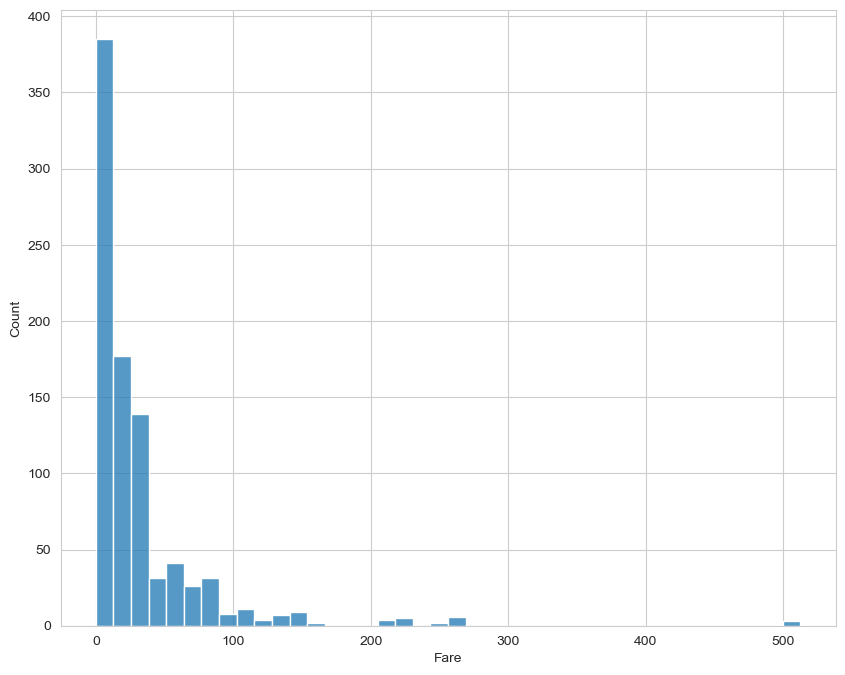

In [104]:
plt.figure(figsize=(10,8))
sns.histplot(x="Fare",data=train, bins = 40)

Fare or ticket price distribution shows that the most of the passengers were paying low price , while the number of high ticket price paid person were very few in number. 

In [105]:
import plotly.express as px

In [106]:
fig = px.histogram(train, x='Fare', color_discrete_sequence=['green'],nbins=40, title="Fare Distribution")
fig.show()

___
## Data Cleaning
We want to fill in missing age data instead of just dropping the missing age data rows. One way to do this is by filling in the mean age of all the passengers (imputation).
However we will do it more smarter ,checking the average age by passenger class. For example:


<Axes: xlabel='Pclass', ylabel='Age'>

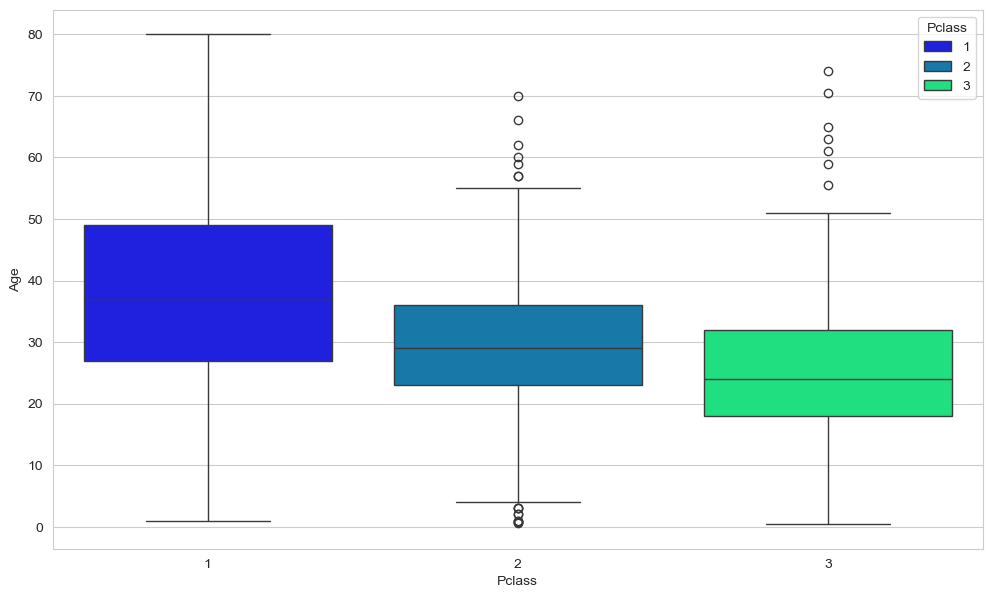

In [107]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass',y='Age',data=train,hue="Pclass", palette="winter")

A trend can be noticed in age of the different class of passenger, for 1st class the age median was around 37, for 2nd class the age median was around 28, for 3rd class the age median was around 24. We are going to impute this age for the missing values according to this class.

In [108]:
#creating a function to do age imputation 
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
        
    else:
        return Age
    

In [109]:
#applying the created function
train['Age'] = train[['Age','Pclass']].apply(impute_age, axis = 1)

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29808\371854408.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29808\371854408.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<Axes: >

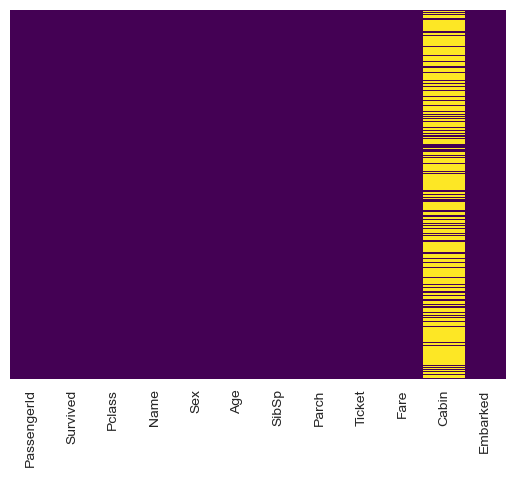

In [110]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

After imputation the null values of Age column is filled

In [111]:
#dropping the cabin column to avoid extra feature engineering
train.drop("Cabin", axis=1, inplace=True)

In [112]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

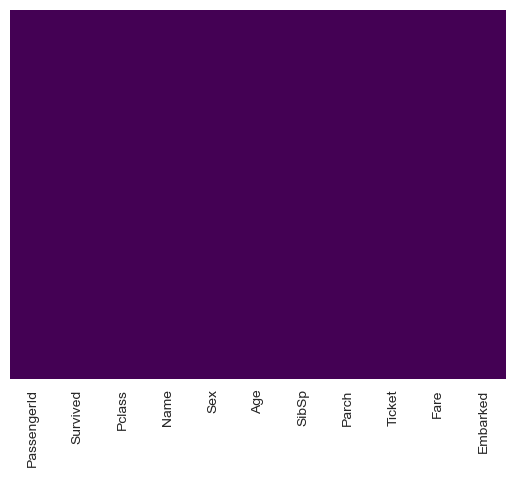

In [113]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

## Converting Categorical Features 

We'll need to convert categorical features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.

In [114]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [115]:
#for Sex column creating 2 dummy columns to that will help to covert the Sex column to numerical format
pd.get_dummies(train['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
886,False,True
887,True,False
888,True,False
889,False,True


In [116]:
train['Embarked'].nunique()

3

In [117]:
sex = pd.get_dummies(train['Sex'], drop_first=True)
embark = pd.get_dummies(train['Embarked'],drop_first=True)

In [118]:
#dropping some unnecessary columns 
train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace=True)

In [119]:
#concatenating the new created columns
train = pd.concat([train, sex, embark], axis = 1)

In [120]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


Our data is ready for our model!

# Building a Logistic Regression model

Let's start by splitting our data into a training set and test set.

## Train Test Split

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
X = train.drop('Survived', axis=1)
y = train['Survived']

In [123]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, 
                                                    random_state=101)

In [125]:
from sklearn.linear_model import LogisticRegression

In [126]:
#creating instance of the model 
logmodel = LogisticRegression()


In [133]:
logmodel.fit(X_train,y_train)

c:\Users\yeasi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [128]:
predictions = logmodel.predict(X_test)

In [129]:
from sklearn.metrics import classification_report

In [130]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81       154
           1       0.78      0.63      0.70       114

    accuracy                           0.77       268
   macro avg       0.77      0.75      0.76       268
weighted avg       0.77      0.77      0.76       268

